In [7]:

import pandas as pd
df = pd.read_csv("surv.csv")

print("Исходный размер:", df.shape)

# 1. удаление пропусков
before = df.shape[0]
df = df.dropna()
after = df.shape[0]
print("Удалено строк с пропусками:", before - after)

# 2. удаление строк с некорректными значениями
q_cols = [f"Q{i}" for i in range(1, 29)]

before = df.shape[0]

df = df[
    (df["instr"].between(1, 3)) &
    (df["class"].between(1, 13)) &
    (df["difficulty"].between(1, 5))
]
for col in q_cols:
    df = df[df[col].between(1, 5)]

after = df.shape[0]
print("Удалено строк с некорректными значениями:", before - after)

# 3. поиск и удаление анкет с одинаковыми ответами по всем вопросам
before = df.shape[0]

# выбираем анкеты, где все ответы одинаковые
same_answer_rows = df[df[q_cols].nunique(axis=1) == 1]

# добавляем столбец со значением этого одинакового ответа
same_answer_rows["same_value"] = same_answer_rows[q_cols[0]]

# считаем, сколько таких анкет для каждого значения ответа
same_answer_counts = same_answer_rows["same_value"].value_counts().sort_index()

print("Количество анкет с одинаковыми ответами по величине ответа:")
print(same_answer_counts)

# удаляем такие анкеты из основного датафрейма
df = df[df[q_cols].nunique(axis=1) > 1]

after = df.shape[0]
print("Удалено анкет с одинаковыми ответами:", before - after)
#4. удаление анкет с нулевым посещением
before = df.shape[0]
df = df[
    (df["attendance"].between(1, 4))]
after = df.shape[0]
print("Удалено анкет с нулевым посещением:", before - after)

print("Итоговый размер:", df.shape)
print(df.head())

df.to_csv("surv-clean.csv", index=False)

Исходный размер: (5820, 33)
Удалено строк с пропусками: 0
Удалено строк с некорректными значениями: 0
Количество анкет с одинаковыми ответами по величине ответа:
same_value
1    550
2    184
3    916
4    747
5    588
Name: count, dtype: int64
Удалено анкет с одинаковыми ответами: 2985
Удалено анкет с нулевым посещением: 741
Итоговый размер: (2094, 33)
    instr  class  nb.repeat  attendance  difficulty  Q1  Q2  Q3  Q4  Q5  ...  \
8       1      2          1           1           3   4   4   4   4   4  ...   
14      1      2          1           2           3   1   1   1   1   1  ...   
15      1      2          1           3           4   5   5   4   4   5  ...   
22      1      2          1           3           3   3   3   3   3   3  ...   
23      1      2          1           2           4   5   3   3   3   2  ...   

    Q19  Q20  Q21  Q22  Q23  Q24  Q25  Q26  Q27  Q28  
8     4    4    4    4    4    4    4    4    4    4  
14    2    3    3    3    2    2    1    1    1    1  

### Анализ выбросов

удаляем все, что выходит из отрезка [Q1−1.5⋅IQR; Q3+1.5⋅IQR]

In [8]:

dff = pd.read_csv("surv-clean.csv")

# выбираем только оценки (Q1–Q28)
cols = [c for c in dff.columns if "Q" in c]


# функция удаления выбросов
def remove_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[~((data < lower) | (data > upper)).any(axis=1)]


clean_dff = remove_outliers(dff[cols])

print("Размер до:", dff.shape)
print("После удаления:", clean_dff.shape)


Размер до: (2094, 33)
После удаления: (1611, 28)


### Матрица корреляций

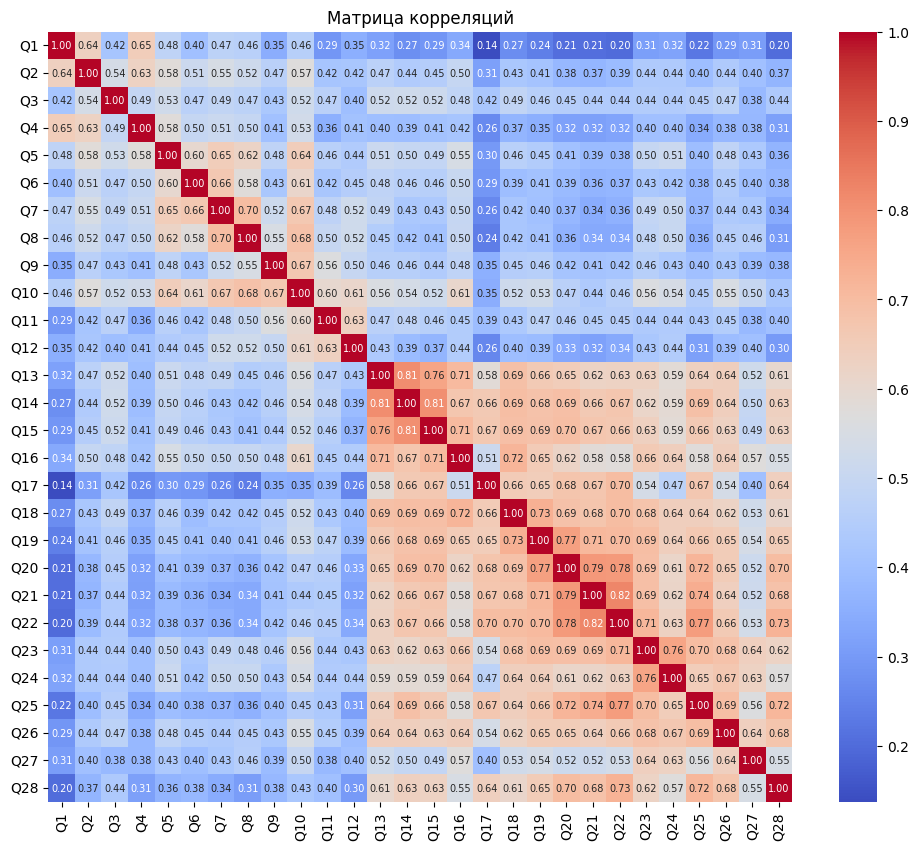

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = clean_dff.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}   # размер чисел внутри ячеек
)

plt.title("Матрица корреляций")
plt.show()

Так как все вопросы сформулированы исключительно так, что чем больше значение ответа, тем положительнее оценка преподавателя, то получаем везде положительную корреляцию
Так заметно, что вопросы Q13–Q28 образуют более плотный блок взаимосвязей: здесь коэффициенты часто находятся примерно в диапазоне 0.6–0.8.
Следовательно, эти показатели описывают близкие аспекты восприятия преподавания и учебного процесса и могут отражать общий фактор – например, общую удовлетворённость качеством курса или работы преподавателя

### Предметы

In [10]:
subjects = df['class'].unique()

for s in subjects[:3]:
    subset = df[df['class'] == s][cols]
    corr_matrix = subset.corr()

    # убираем единицы на диагонали
    corr_values = corr_matrix.values
    n = corr_values.shape[0]

    mean_corr = (corr_values.sum() - n) / (n * n - n)

    print(f"\nПредмет {s}")
    print("Средняя корреляция:", mean_corr)


Предмет 2
Средняя корреляция: 0.5710638495793654

Предмет 7
Средняя корреляция: 0.601067560579786

Предмет 10
Средняя корреляция: 0.6448900172817804


По результатам сравнения предмет 10 характеризуется наибольшей средней корреляцией между признаками, предмет 7 занимает промежуточное положение, а предмет 2 – наименьшее. Следовательно, ответы студентов по предмету 10 более согласованы, чем по предметам 7 и 2.

### Анализ преподавателей

In [11]:

teacher_stats = dff.groupby("instr")[cols].mean()

print("\nОписательная статистика преподавателей:")
print(teacher_stats.describe())

teacher_stats["rating"] = teacher_stats.mean(axis=1)

print("\nРейтинг преподавателей:")
print(teacher_stats.sort_values("rating", ascending=False))



Описательная статистика преподавателей:
             Q1        Q2        Q3        Q4        Q5        Q6        Q7  \
count  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
mean   2.788432  3.096920  3.313998  3.087989  3.200650  3.110294  3.066416   
std    0.231174  0.215092  0.160943  0.174413  0.273945  0.111602  0.211246   
min    2.529231  2.849231  3.129231  2.886923  2.905385  3.002308  2.834615   
25%    2.696006  3.027059  3.259164  3.032747  3.077692  3.052846  2.975578   
50%    2.862782  3.204887  3.389098  3.178571  3.250000  3.103383  3.116541   
75%    2.918032  3.220764  3.406381  3.188522  3.348282  3.164287  3.182316   
max    2.973282  3.236641  3.423664  3.198473  3.446565  3.225191  3.248092   

             Q8        Q9       Q10  ...       Q19       Q20       Q21  \
count  3.000000  3.000000  3.000000  ...  3.000000  3.000000  3.000000   
mean   3.079166  3.260833  3.120458  ...  3.496806  3.491801  3.518919   
std    0.367983  0.169355

### Анализ предметов


Рейтинг предметов:
             Q1        Q2        Q3        Q4        Q5        Q6        Q7  \
class                                                                         
2      2.850000  3.200000  3.200000  3.050000  3.625000  3.375000  3.425000   
1      2.941748  3.339806  3.514563  3.281553  3.388350  3.291262  3.349515   
6      2.857843  3.200980  3.421569  3.186275  3.269608  3.294118  3.250000   
10     3.231343  3.395522  3.470149  3.388060  3.440299  3.470149  3.380597   
12     3.000000  3.529412  3.529412  3.294118  3.058824  3.058824  2.941176   
11     2.869565  3.146739  3.298913  3.108696  3.190217  2.809783  2.913043   
7      2.636364  3.011364  3.454545  2.977273  3.375000  2.784091  2.965909   
8      2.325581  2.844961  3.344961  2.856589  2.821705  3.089147  2.829457   
5      2.844106  3.110266  3.083650  3.140684  3.178707  3.285171  2.996198   
9      2.497608  2.822967  3.220096  2.894737  2.899522  3.153110  2.923445   
3      2.650000  2.880769  3.115

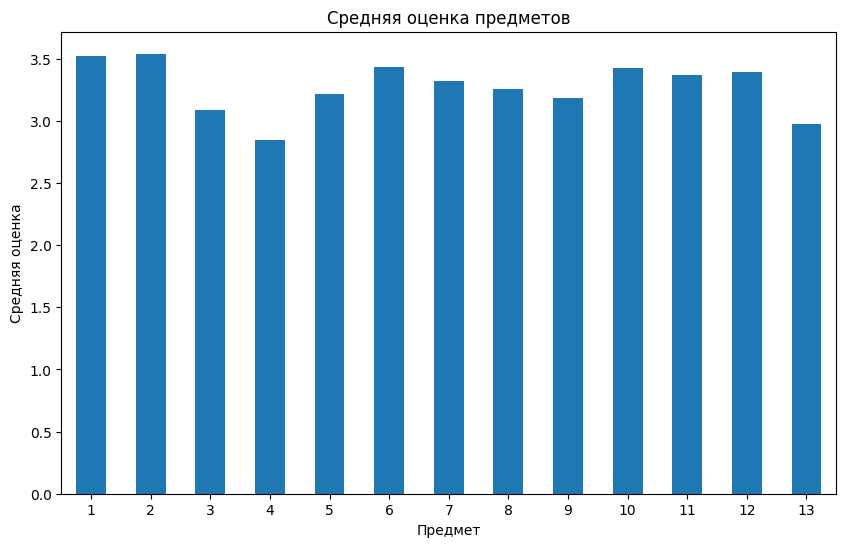

In [12]:

import pandas as pd
import matplotlib.pyplot as plt

subject_stats = df.groupby("class")[cols].mean()

subject_stats["rating"] = subject_stats.mean(axis=1)

print("\nРейтинг предметов:")
print(subject_stats.sort_values("rating", ascending=False))

# график средней оценки предметов
plt.figure(figsize=(10, 6))
subject_stats["rating"].plot(kind="bar")

plt.title("Средняя оценка предметов")
plt.xlabel("Предмет")
plt.ylabel("Средняя оценка")
plt.xticks(rotation=0)

plt.show()
